## Go Through the raw/README.txt for revising the Topic, Data adn all..

In [375]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Goal

To predict the Remaining Useful Life (RUL) of an aircraft engine we need to predict exactly how many operational cycles an engine has left before it completely fails.

## The Data (FD001)

* We are looking at time-series data from a fleet of identical turbofan engines.
* Each engine starts with a different degree of initial, normal wear.
* As time goes on, the engine develops a fault (specifically, High-Pressure Compressor or "HPC" Degradation).

* Train Set : This contains data from 100 different engines. The data records the engine's life until it completely break (system failure). This teaches the model what death looks like.

* Test Set: This contains data from 100 different engines. The recording cuts off before failure. so the ML model has to look at where the data stopped and guess how many cycles are left.

* RUL_FD001.txt (The Answer Key): This file literally just contains a list of numbers. It is the true Remaining Useful Life values for the the engines in test data. We use this to calculate the RMSE and see if the model's guesses were accurate.

$$RUL = \text{Max\_Cycles} - \text{Current\_Cycle}$$

## The Columns (26 Total)
The raw .txt file has 26 columns of numbers separated by spaces. Here is the decoder ring:
* Column 1: Unit number (The Engine ID, e.g., Engine 1, Engine 2).

* Column 2: Time, in cycles (e.g., Cycle 1, Cycle 2,) (The "age" of the engine at that moment).

* Columns 3-5: Operational Settings (Three settings that heavily impact engine performance). (Altitude, Mach number, etc.)

* Columns 6-26: Sensor Measurements 1 through 21 (Data from 21 different sensors, which includes realistic sensor noise). (Temperatures, Pressures, Fan speeds).


#### Total Columns: 1 (Unit) + 1 (Time) + 3 (Settings) + 21 (Sensors) = 26 Columns.


## Some Important Observation from The readme.txt documentation provided:


* In the training set, the fault grows in magnitude until system failure.
If Engine #1 died at cycle 192, we must teach the model that at cycle 1, it had 191 cycles left. At cycle 190, it had 2 cycles left. (we must calculate this RUL column)

* In the test set, the time series ends some time prior to system failure.
so we Predict when they will die.


* RUL file having exactly 100 rows while the train and test files have thousands of rows

* The train and test datasets have one row for every single operational cycle of an engine. So if Engine #1 ran for 192 cycles, it takes up 192 rows. But the RUL file only has one single final answer per engine.

### Loading & Structuring the DATA : Train Data

Since the (.txt) file is just numbers separated by spaces  and has no header row, if we just use pd.read_csv(), *pandas will mistakenly use the first row of data as the column names. We have to build the column names ourselves !!

In [376]:
## 1. Defining the Column Names :-

# based on Documentation, we know the first 5 columns are these:
columns = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3']

# Now rest we have 21 sensors. Instead of typing them all out, let's use a quick loop to generate 's_1', 's_2', etc.
for i in range(1, 22):
    columns.append(f's_{i}')

In [377]:
## 2. Loading the Data :-

# Observe the train.txt file, The columns are separated by smaces !!

# sep='\s+': This tells Pandas that the columns are separated by spaces, not commas.

# names=columns: This tells Pandas to use the list we just made as the headers

train_df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', names=columns)



In [378]:
print(f"Data Loaded! Shape: {train_df.shape}")
train_df.head()

Data Loaded! Shape: (20631, 26)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### ---------------------------------------------------------------------

## target/output(y) i.e. RUL integration:

Now, Before we can look for patterns or clean up the sensors, we absolutely must create our Target Variable (the "Answer" we want our model to predict). 

Right now, we have the inputs (X), but we have no output (y)

for, RUL = max_cycle - current_cycles

Since the training set data runs until the engine experiences a system failure, the very last cycle recorded for an engine is its *maximum lifespan*.

In [ ]:
#Group the data by engine (unit_nr) and find the maximum cycle for each engine
max_cycles_df = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()


In [380]:
max_cycles_df.head()

,unit_nr,time_cycles
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [ ]:
# Rename the column so we don't confuse it with the current 'time_cycles'
max_cycles_df.rename(columns={'time_cycles': 'max_cycle'}, inplace=True)
max_cycles_df.head()

,unit_nr,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [ ]:
# Merge 'max_cycle' number back into our main training dataframe
# We use a 'left' merge on 'unit_nr' so every row gets its engine's max_cycle attached to it.
train_df = pd.merge(train_df, max_cycles_df, on='unit_nr', how='left')
train_df.head(10)

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,192
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,192
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,192
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,192
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,192


In [ ]:
# ** Here we Calculate RUL and put it inside
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
train_df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [ ]:
# Now we don't need the 'max_cycle' column anymore, so let's drop it to keep our data clean.
train_df.drop('max_cycle', axis=1, inplace=True)

In [ ]:
# verify
print(train_df[['unit_nr', 'time_cycles', 'RUL']].head(10))

   unit_nr  time_cycles  RUL
0        1            1  191
1        1            2  190
2        1            3  189
3        1            4  188
4        1            5  187
5        1            6  186
6        1            7  185
7        1            8  184
8        1            9  183
9        1           10  182


________________________________________________________________________________

# EDA

In [386]:
train_df.head()


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [387]:
train_df.shape

(20631, 27)

In [388]:
train_df.isnull().sum() # no null values, all good !

unit_nr        0
time_cycles    0
setting_1      0
setting_2      0
setting_3      0
s_1            0
s_2            0
s_3            0
s_4            0
s_5            0
s_6            0
s_7            0
s_8            0
s_9            0
s_10           0
s_11           0
s_12           0
s_13           0
s_14           0
s_15           0
s_16           0
s_17           0
s_18           0
s_19           0
s_20           0
s_21           0
RUL            0
dtype: int64

In [389]:
train_df.duplicated() # all good, no duplicates

0        False
1        False
2        False
3        False
4        False
         ...  
20626    False
20627    False
20628    False
20629    False
20630    False
Length: 20631, dtype: bool

In [390]:
train_df.info() # all columns are numeric, no categorical variables, all good !

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_nr      20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   s_1          20631 non-null  float64
 6   s_2          20631 non-null  float64
 7   s_3          20631 non-null  float64
 8   s_4          20631 non-null  float64
 9   s_5          20631 non-null  float64
 10  s_6          20631 non-null  float64
 11  s_7          20631 non-null  float64
 12  s_8          20631 non-null  float64
 13  s_9          20631 non-null  float64
 14  s_10         20631 non-null  float64
 15  s_11         20631 non-null  float64
 16  s_12         20631 non-null  float64
 17  s_13         20631 non-null  float64
 18  s_14         20631 non-null  float64
 19  s_15

In [391]:
train_df.describe().T # observe the standard deviation !

,count,mean,std,min,25%,50%,75%,max
unit_nr,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


* we see some sensors are having standard deviation almost 0 . This is BAD !

* If a sensor's value never changes, it has zero predictive power. It cannot tell us if the engine is healthy or dying. If we feed these to our model, it just adds noise and slows down training. 
* I am assuming based on some sensores are turned off or brokem !! so always 0 reading or measuring constant value for so long like 100 or something.

In [392]:

std_devs = train_df.std()

useless_cols = std_devs[std_devs == 0].index.tolist()
print("Useless columns detected:", useless_cols)

# Dropping those
train_df = train_df.drop(columns=useless_cols)
print("New Shape after dropping:", train_df.shape)

Useless columns detected: ['setting_3', 's_1', 's_10', 's_18', 's_19']
New Shape after dropping: (20631, 22)


## Histogram !

* Look for skewness (for regression)

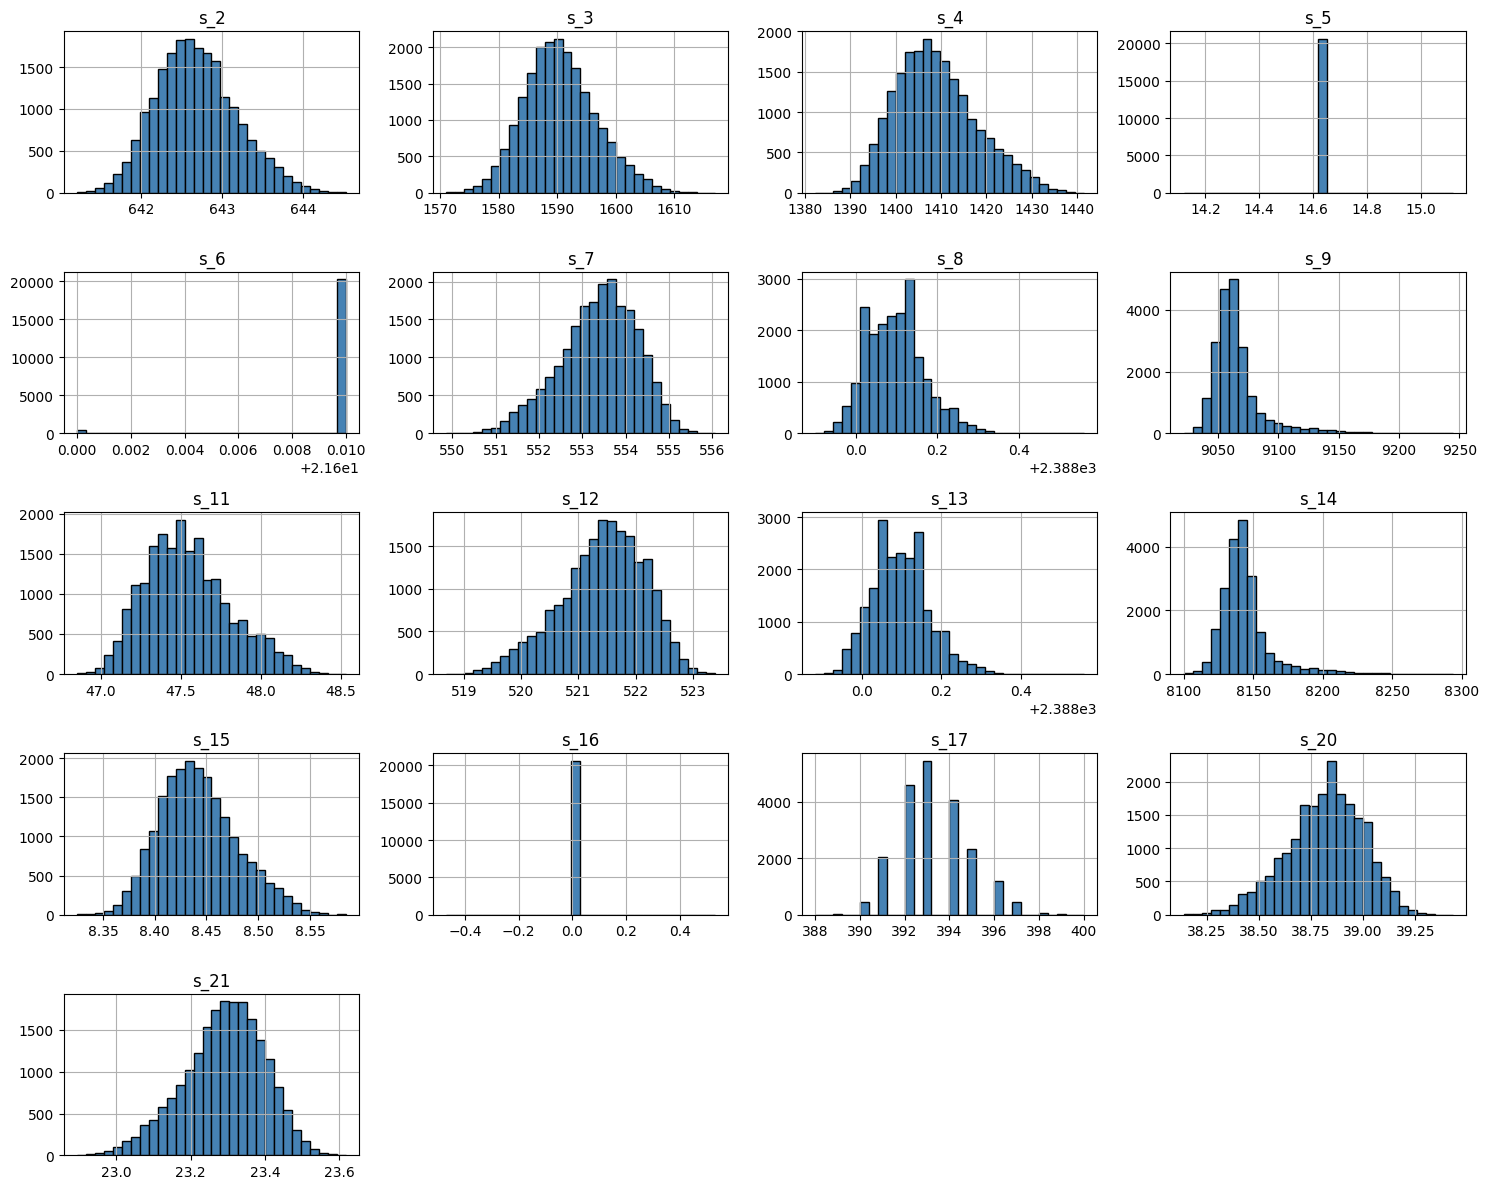

In [393]:
import matplotlib.pyplot as plt
'''
for col in train_df.columns:
    train_df[col].hist(bins=30)
    plt.title(col)
    plt.show()
'''   
# But we do want for all columns at once, so let's do it in a grid!


# 1. Grab only the sensor columns (we don't need histograms for Engine ID or Time)
sensor_columns = [col for col in train_df.columns if 's_' in col]

# 2. Plot all of them at once in a grid!
# bins=30 controls how granular the bars are. figsize makes the image big enough to read.
train_df[sensor_columns].hist(bins=30, figsize=(15, 12), color='steelblue', edgecolor='black')

# 3. Clean up the spacing so titles don't overlap, and show it
plt.tight_layout()
plt.show()

#### Histogram counts how many rows have a certain sensor value ?

* X-axis (horizontal) : ranges of sensor values
* Y-axis (vertical) : Number of rows that contain that value

* we gotta remove s_5, s_6, s_16 as they are almost constant at a certain value for all the rows !! Model can not learn anything from it. Noise !

* s_8, s_9, s_13, s_14 have skewness (Right skew) so we may use Log Transform else use Tree to handle it.

* s_17 may look weird but not dropping without valid logic

In [394]:
train_df = train_df.drop(columns=['s_5','s_6','s_16'])

In [395]:
train_df.columns

Index(['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 's_2', 's_3', 's_4',
       's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17',
       's_20', 's_21', 'RUL'],
      dtype='object')

In [396]:
train_df.shape

(20631, 19)

# Co-Relation :

* Purpose: Which sensors actually influence engine failure (RUL) and which are redundant

In [397]:
## Bi-Variate Analysis :-

corr_matrix = train_df.corr()

rul_correlation = corr_matrix['RUL'].sort_values(ascending=False)

print(rul_correlation)

'''
Note:

| Value           | Meaning                      |
| --------------- | ---------------------------- |
| **+1**          | Perfect positive correlation |
| **0.7 - 0.9**   | Strong correlation           |
| **0**           | No relationship              |
| **-0.7 - -0.9** | Strong negative correlation  |
| **-1**          | Perfect negative correlation |
--------------------------------------------------

'''

RUL            1.000000
s_12           0.671983
s_7            0.657223
s_21           0.635662
s_20           0.629428
unit_nr        0.078753
setting_2     -0.001948
setting_1     -0.003198
s_14          -0.306769
s_9           -0.390102
s_13          -0.562569
s_8           -0.563968
s_3           -0.584520
s_17          -0.606154
s_2           -0.606484
s_15          -0.642667
s_4           -0.678948
s_11          -0.696228
time_cycles   -0.736241
Name: RUL, dtype: float64


'\nNote:\n\n| Value           | Meaning                      |\n| --------------- | ---------------------------- |\n| **+1**          | Perfect positive correlation |\n| **0.7 - 0.9**   | Strong correlation           |\n| **0**           | No relationship              |\n| **-0.7 - -0.9** | Strong negative correlation  |\n| **-1**          | Perfect negative correlation |\n--------------------------------------------------\n\n'

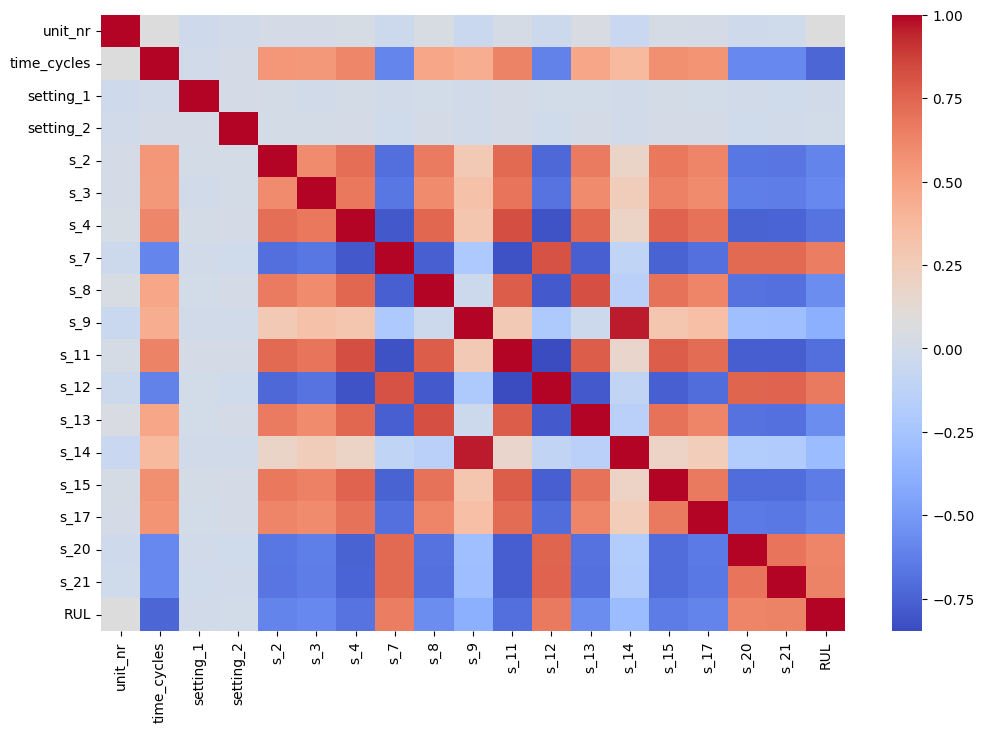

In [398]:
# Correlation Heatmap
## Multi-Collinearity

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

### Observations :-

* setting-1 and 2 are garbage

* s_9 and s_14 (Dark Red) i.e. Zero correlation
 *Can Drop * but we can use XGBoost Later, so lets keep em


* Note: - Correlation only captures linear relationships.
Sometimes sensors have non-linear patterns, which ML models can still learn.
So we don't drop features only based on correlation.

* s_4, s_11 and s_12, s_7 has the strongest Co-relation with RUL !! see Heatmap and matrix both --> we go their plot against time-cycle 
* (*NOTE:-  This is waht we do for Time-series Datasets )


In [399]:
# Drop the useless settings
train_df = train_df.drop(columns=['setting_1', 'setting_2'])

In [400]:
train_df.head()

,unit_nr,time_cycles,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [ ]:
train_df.columns

Index(['unit_nr', 'time_cycles', 's_2', 's_3', 's_4', 's_7', 's_8', 's_9',
       's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'RUL'],
      dtype='object')

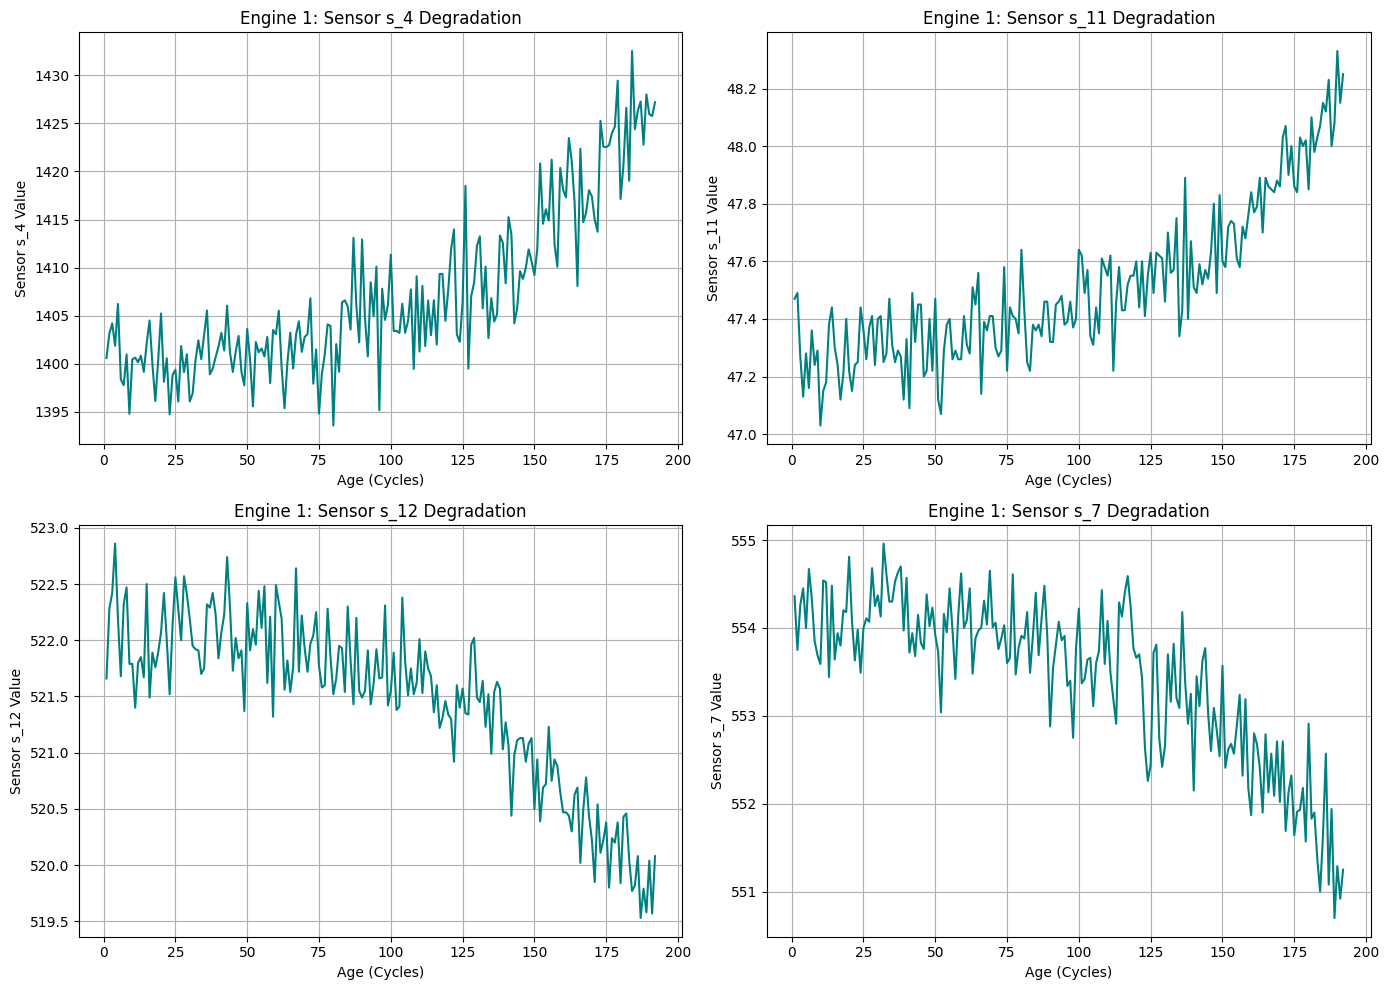

In [402]:
import matplotlib.pyplot as plt

# We pick our top MVP sensors identified by the Heatmap
top_sensors = ['s_4', 's_11', 's_12', 's_7'] 

# Isolate just Engine #1 so we can watch one single life from start to death
engine_1_data = train_df[train_df['unit_nr'] == 1]

# Set up a 2x2 grid of plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten() # This flattens the 2x2 grid into a simple list of 4 plots to make looping easy

# 4. The Loop: Plot each sensor in its own box
for i, sensor in enumerate(top_sensors):
    axes[i].plot(engine_1_data['time_cycles'], engine_1_data[sensor], color='teal', linewidth=1.5)
    axes[i].set_title(f'Engine 1: Sensor {sensor} Degradation')
    axes[i].set_xlabel('Age (Cycles)')
    axes[i].set_ylabel(f'Sensor {sensor} Value')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Observations:

* The Trend: Notice how s_4 and s_11 slowly curve upwards, while s_12 and s_7 slowly curve downwards as the cycles increase. This proves the engine is physically degrading.

* The Noise: Look closely at the lines themselves. They aren't perfectly smooth. Too much VIBRATIONS !! --> going for the Rolling mean and std (* This is what we go for generally in such datasets)

___________________________________________________________________________

### Observation: 

* The data is Noisy... > Vibrations

* Feature Enginnering:
* calculating the Rolling Mean (to capture the curve) 
* Rolling Standard Deviation (to capture the saw blade)

## Feature Engineering

In [403]:
# Define the sensors we want to calculate rolling features for all the remaining sensors !!
sensor_cols = [col for col in train_df.columns if 's_' in col]

# Memory Windwo size
window_size = 5

# !! use Copy of Original Data
df_engineered = train_df.copy()

#  Loop: Calculate Mean and Std for every sensor
for sensor in sensor_cols:
    
    # Calculate Rolling Mean (Trend)
    # We GROUP BY 'unit_nr' so Engine 2's cycle 1 doesn't average with Engine 1's cycle 200!
    df_engineered[f'{sensor}_mean'] = df_engineered.groupby('unit_nr')[sensor].transform(lambda x: x.rolling(window_size).mean())
    
    # Calculate Rolling Standard Deviation (Vibration)
    df_engineered[f'{sensor}_std'] = df_engineered.groupby('unit_nr')[sensor].transform(lambda x: x.rolling(window_size).std())

# ** Drop the rows with NaN (The first 4 cycles of every engine won't have 5 previous cycles to average, so they become NaN) **
df_engineered = df_engineered.dropna()

print(f"Old Shape: {train_df.shape}")
print(f"New Shape: {df_engineered.shape}")

Old Shape: (20631, 17)
New Shape: (20231, 45)


In [404]:
df_engineered.columns

Index(['unit_nr', 'time_cycles', 's_2', 's_3', 's_4', 's_7', 's_8', 's_9',
       's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'RUL',
       's_2_mean', 's_2_std', 's_3_mean', 's_3_std', 's_4_mean', 's_4_std',
       's_7_mean', 's_7_std', 's_8_mean', 's_8_std', 's_9_mean', 's_9_std',
       's_11_mean', 's_11_std', 's_12_mean', 's_12_std', 's_13_mean',
       's_13_std', 's_14_mean', 's_14_std', 's_15_mean', 's_15_std',
       's_17_mean', 's_17_std', 's_20_mean', 's_20_std', 's_21_mean',
       's_21_std'],
      dtype='object')

_____________________________________________________________________________________

## Loading and Merging the Test Data

We need to load the test data using the exact same columns as the train data, and then we need to carefully attach the true RUL values to the very last cycle of each engine.

In [405]:
#  Loading Test Data (using the exact same 26 original columns we defined at the very beginning)
# NOTE:- 'columns' was the list of 26 names: unit_nr, time_cycles, setting_1... s_21


test_df = pd.read_csv('../data/raw/test_FD001.txt', sep=r'\s+', names=columns)

In [406]:
test_df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [407]:
# Loading the Answer Key
# Since it's just a raw list of numbers with no header, we tell Pandas header=None and we name the column 'True_RUL' ourselves.
y_test = pd.read_csv('../data/raw/RUL_FD001.txt', sep=r'\s+', header=None, names=['True_RUL'])

In [408]:
y_test.head()

,True_RUL
0,112
1,98
2,69
3,82
4,91


### Note

Now we see, RUL_FD001.txt has a vertical lsit of 100 numbers, each row represents each Engine. Though there are no engine names Given ! and There are no column headers. But the documentation for the dataset tells us: The answers are in perfect order. 
* The 1st number (112) is the answer for Engine 1.
* The 2nd number (98) is the answer for Engine 2.

Now, pandas pd.read_csv also creates an index on far left, as we see above. If we try to match "Engine 0" to our test data, it will crash, because our engines are named 1, 2, 3... up to 100!

* The Solution: y_test.index + 1

We need to create a brand new column called 'unit_nr' (Engine ID) so we can pair these answers with the correct engines later. Instead of typing out 1 to 100 manually, we tell Pandas: "Hey, take your automatic row counter (the index), add 1 to every single row, and save that as the Engine ID!"

* Row 0 + 1 = Engine 1

* Row 1 + 1 = Engine 2

* Row 2 + 1 = Engine 3

In [409]:
# so let's Give the Answer Key some Engine IDs
# The answers are perfectly in order from Engine 1 to 100. 
# [y_test.index] = This returns the row index values of the DataFrame.
# Pandas index starts at 0, so we just add 1 to create the Engine IDs!
y_test['unit_nr'] = y_test.index + 1 

print("Test df Shape:", test_df.shape)
print("Answer Key Shape:", y_test.shape)

Test df Shape: (13096, 26)
Answer Key Shape: (100, 2)


In [410]:
y_test.head()

,True_RUL,unit_nr
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


####  Now, we know in test_df, 

* Engine 1's data might cut off at Cycle 31.

* Engine 2's data might cut off at Cycle 140.


In [411]:
# 1. Group by engine, and grab the maximum (last) cycle recorded for each
test_max_cycles = test_df.groupby('unit_nr')['time_cycles'].max().reset_index()

In [412]:
test_max_cycles.head()

,unit_nr,time_cycles
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


In [413]:
#Rename that column so we don't confuse it with the normal 'time_cycles'
test_max_cycles.rename(columns={'time_cycles': 'max_cycle'}, inplace=True)

In [414]:
test_max_cycles.head()

,unit_nr,max_cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


In [415]:
# 1. Attach the 'max_cycle' (e.g., 31) to every row of its respective engine
test_df = pd.merge(test_df, test_max_cycles, on='unit_nr', how='left')

# 2. Attach the 'True_RUL' (e.g., 112) from the answer key to every row
test_df = pd.merge(test_df, y_test, on='unit_nr', how='left')

In [416]:
test_df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,max_cycle,True_RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,31,112
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,31,112
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,31,112
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,31,112
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,31,112


In [417]:


# 3. The Math: Calculate the exact RUL for every single cycle!
# Total Lifespan minus the Current Cycle
test_df['RUL'] = test_df['True_RUL'] + test_df['max_cycle'] - test_df['time_cycles']

# 4. We don't need 'max_cycle' or 'True_RUL' anymore, so let's drop them to keep it clean
test_df.drop(['max_cycle', 'True_RUL'], axis=1, inplace=True)


In [418]:
test_df[['unit_nr', 'time_cycles', 'RUL']].head()

,unit_nr,time_cycles,RUL
0,1,1,142
1,1,2,141
2,1,3,140
3,1,4,139
4,1,5,138


In [419]:
test_df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


### Mirroring the Feature Engineering

We just need to run the exact same cleanup and rolling loop on test_df that we did on the training data.

In [420]:
cols_to_drop = ['setting_1', 'setting_2', 'setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

test_df_clean = test_df.drop(columns=cols_to_drop)

In [421]:

# Set up the exact same Rolling Window Memory
window_size = 5
test_engineered = test_df_clean.copy()

# Grab the remaining good sensors
sensor_cols = [col for col in test_df_clean.columns if 's_' in col]

# The exact same loop for Mean and Std
for sensor in sensor_cols:
    test_engineered[f'{sensor}_mean'] = test_engineered.groupby('unit_nr')[sensor].transform(lambda x: x.rolling(window_size).mean())
    test_engineered[f'{sensor}_std'] = test_engineered.groupby('unit_nr')[sensor].transform(lambda x: x.rolling(window_size).std())

# Dropping the first 4 cycles (NaNs) just like we did for train
test_engineered = test_engineered.dropna()



In [422]:
print("Train Data Columns:", len(df_engineered.columns))
print("Test Data Columns:", len(test_engineered.columns))

Train Data Columns: 45
Test Data Columns: 45


In [423]:
df_engineered.head()

,unit_nr,time_cycles,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,...,s_14_mean,s_14_std,s_15_mean,s_15_std,s_17_mean,s_17_std,s_20_mean,s_20_std,s_21_mean,s_21_std
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,...,8134.194,2.651326,8.41334,0.025953,391.8,1.095445,38.958,0.073621,23.39302,0.033498
5,1,6,642.10,1584.47,1398.37,554.67,2388.02,9049.68,47.16,521.68,...,8133.040,0.958697,8.41160,0.025727,391.6,1.140175,38.942,0.051186,23.38260,0.031436
6,1,7,642.48,1592.32,1397.77,554.34,2388.02,9059.13,47.36,522.32,...,8133.206,0.643141,8.40472,0.023476,391.6,1.140175,38.962,0.086718,23.37336,0.021634
7,1,8,642.56,1582.96,1400.97,553.85,2388.00,9040.80,47.24,522.47,...,8132.774,1.149274,8.40268,0.022477,391.8,0.836660,38.966,0.086487,23.36664,0.034405
8,1,9,642.12,1590.98,1394.80,553.69,2388.05,9046.46,47.29,521.79,...,8131.146,3.205438,8.40360,0.020740,391.8,0.836660,39.000,0.077136,23.37318,0.038939


In [424]:
# Resetting the index of both 

df_engineered = df_engineered.reset_index(drop=True)

test_engineered = test_engineered.reset_index(drop=True)



In [425]:
test_engineered[['unit_nr', 'time_cycles', 'RUL']].head()

,unit_nr,time_cycles,RUL
0,1,5,138
1,1,6,137
2,1,7,136
3,1,8,135
4,1,9,134


_______________________________________________________________________________________

## Saving both of the engineered df

In [426]:
# Save our engineered datasets to CSV files

import os

save_dir = '../data/processed/'

df_engineered.to_csv(os.path.join(save_dir, 'train_engineered.csv'), index=False)
test_engineered.to_csv(os.path.join(save_dir, 'test_engineered.csv'), index=False)

print("Checkpoints saved successfully!")

Checkpoints saved successfully!
